<a href="https://colab.research.google.com/github/Willi-blip/numpy1/blob/main/ExamenFinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

EJERCICIO 1

Dataset MNIST cargado exitosamente.

## 📏 Dimensiones de los Conjuntos de Datos
Dimensiones de las imágenes de entrenamiento (x_train): **(60000, 28, 28)**
Dimensiones de las etiquetas de entrenamiento (y_train): **(60000,)**
Dimensiones de las imágenes de prueba (x_test): **(10000, 28, 28)**
Dimensiones de las etiquetas de prueba (y_test): **(10000,)**

## 🖼️ Visualización de 10 Imágenes y Etiquetas


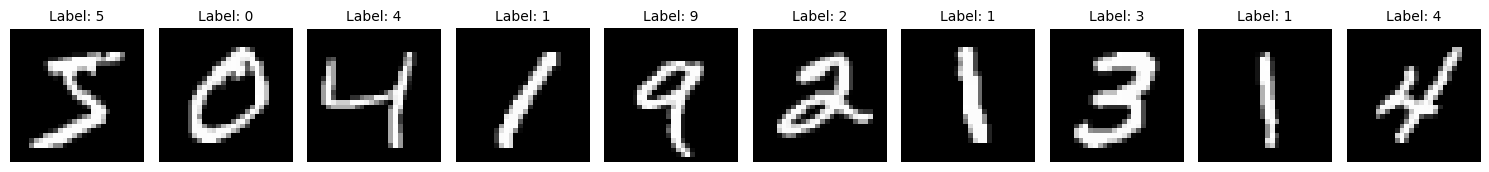

In [16]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Cargar el dataset MNIST
try:
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
    print("Dataset MNIST cargado exitosamente.")
except Exception as e:
    print(f"Error al cargar el dataset MNIST: {e}")

# Mostrar las dimensiones

print("\n## 📏 Dimensiones de los Conjuntos de Datos")

print(f"Dimensiones de las imágenes de entrenamiento (x_train): **{x_train.shape}**")
print(f"Dimensiones de las etiquetas de entrenamiento (y_train): **{y_train.shape}**")
print(f"Dimensiones de las imágenes de prueba (x_test): **{x_test.shape}**")
print(f"Dimensiones de las etiquetas de prueba (y_test): **{y_test.shape}**")


# Visualizar 10 imágenes con sus etiquetas
print("\n## 🖼️ Visualización de 10 Imágenes y Etiquetas")


plt.figure(figsize=(15, 3))


for i in range(10):

    plt.subplot(1, 10, i + 1)


    plt.imshow(x_train[i], cmap='gray')


    plt.title(f"Label: {y_train[i]}", fontsize=10)


    plt.axis('off')

plt.tight_layout()
plt.show()



EJERCICIO 2

In [17]:
#Normalizar valores pixeleados
x_train_normalized = x_train.astype('float32') / 255.0
x_test_normalized = x_test.astype('float32') / 255.0

print("\n## ✨ Valores de Píxeles Normalizados")
print(f"Valor máximo en x_train_normalized: **{np.max(x_train_normalized)}**")
print(f"Valor mínimo en x_train_normalized: **{np.min(x_train_normalized)}**")
print(f"Valor máximo en x_test_normalized: **{np.max(x_test_normalized)}**")
print(f"Valor mínimo en x_test_normalized: **{np.min(x_test_normalized)}**")


## ✨ Valores de Píxeles Normalizados
Valor máximo en x_train_normalized: **1.0**
Valor mínimo en x_train_normalized: **0.0**
Valor máximo en x_test_normalized: **1.0**
Valor mínimo en x_test_normalized: **0.0**


In [18]:
#Convierte las etiquetas en formato one-hot encoding utilizando to_categorical
num_classes = 10  # MNIST tiene 10 clases
y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes)
y_test_one_hot = tf.keras.utils.to_categorical(y_test, num_classes)

print("\n## 🔥 Etiquetas en Formato One-Hot Encoding")
print(f"dimensiones de las etiquetas de entrenamiento one-hot (y_train_one_hot): **{y_train_one_hot.shape}**")
print(f"dimensiones de las etiquetas de prueba one-hot (y_test_one_hot): **{y_test_one_hot.shape}**")
print(f"ejemplo de etiqueta originales (y_train[0]): **{y_train[0]}**")
print(f"ejemplo de etiqueta one-hot (y_train_one_hot[0]): **{y_train_one_hot[0]}**")


## 🔥 Etiquetas en Formato One-Hot Encoding
dimensiones de las etiquetas de entrenamiento one-hot (y_train_one_hot): **(60000, 10)**
dimensiones de las etiquetas de prueba one-hot (y_test_one_hot): **(10000, 10)**
ejemplo de etiqueta originales (y_train[0]): **5**
ejemplo de etiqueta one-hot (y_train_one_hot[0]): **[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]**


EJERCCIO 3

In [19]:
# Aplanar las imágenes de entrenamiento
x_train_flattened = x_train_normalized.reshape(x_train_normalized.shape[0], -1)

# Aplanar las imágenes de prueba
x_test_flattened = x_test_normalized.reshape(x_test_normalized.shape[0], -1)

# Seleccionar un subconjunto de 10,000 imágenes de entrenamiento aplanadas
x_train_subset = x_train_flattened[:10000]

# Seleccionar las etiquetas correspondientes al subconjunto de entrenamiento
y_train_subset = y_train[:10000]

print("\n## 🔄 Imágenes Redimensionadas y Subconjunto Seleccionado")
print(f"dimensiones de las imágenes de entrenamiento aplanadas (x_train_flattened): **{x_train_flattened.shape}**")
print(f"dimensiones de las imágenes de prueba aplanadas (x_test_flattened): **{x_test_flattened.shape}**")
print(f"dimensiones del subconjunto de entrenamiento (x_train_subset): **{x_train_subset.shape}**")
print(f"dimensiones de las etiquetas del subconjunto de entrenamiento (y_train_subset): **{y_train_subset.shape}**")


## 🔄 Imágenes Redimensionadas y Subconjunto Seleccionado
Dimensiones de las imágenes de entrenamiento aplanadas (x_train_flattened): **(60000, 784)**
Dimensiones de las imágenes de prueba aplanadas (x_test_flattened): **(10000, 784)**
Dimensiones del subconjunto de entrenamiento (x_train_subset): **(10000, 784)**
Dimensiones de las etiquetas del subconjunto de entrenamiento (y_train_subset): **(10000,)**


In [20]:
from sklearn.svm import SVC

svm_classifier = SVC()

svm_classifier.fit(x_train_subset, y_train_subset)

print("\n## 💪 Clasificador SVM entrenado exitosamente")


## 💪 Clasificador SVM entrenado exitosamente


In [21]:
from sklearn.metrics import accuracy_score

y_pred = svm_classifier.predict(x_test_flattened)

accuracy = accuracy_score(y_test, y_pred)

print(f"\n## 🎯 Exactitud del modelo SVM en el conjunto de prueba: **{accuracy:.4f}**")


## 🎯 Exactitud del modelo SVM en el conjunto de prueba: **0.9594**


In [22]:
typical_nn_accuracy = 0.98

print("\n## 📊 Comparación de Rendimiento: SVM vs. Redes Neuronales")
print(f"Exactitud del modelo SVM en el conjunto de prueba: **{accuracy:.4f}**")
print(f"Exactitud típica de una Red Neuronal Estándar en MNIST: **{typical_nn_accuracy:.4f}**")

print("\n**Discusión:**")
print(f"- El modelo SVM entrenado con un subconjunto de 10,000 imágenes de entrenamiento logró una exactitud de **{accuracy:.4f}** en el conjunto de prueba.")
print(f"- Las redes neuronales estándar suelen alcanzar una exactitud más alta en el dataset MNIST, entre 97% y 99%.")
print("- En este caso, la red neuronal supera al SVM en términos de exactitud.")
print("- Factores que podrían influir en esta diferencia incluyen:")
print("   .El tamaño del conjunto de entrenamiento")
print("   .La complejidad del modelo")


## 📊 Comparación de Rendimiento: SVM vs. Redes Neuronales
Exactitud del modelo SVM en el conjunto de prueba: **0.9594**
Exactitud típica de una Red Neuronal Estándar en MNIST: **0.9800**

**Discusión:**
- El modelo SVM entrenado con un subconjunto de 10,000 imágenes de entrenamiento logró una exactitud de **0.9594** en el conjunto de prueba.
- Las redes neuronales estándar suelen alcanzar una exactitud más alta en el dataset MNIST, entre 97% y 99%.
- En este caso, la red neuronal supera al SVM en términos de exactitud.
- Factores que podrían influir en esta diferencia incluyen:
   .El tamaño del conjunto de entrenamiento
   .La complejidad del modelo


EJERCICIO 4

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Construir el modelo MLP
model = Sequential([
    Flatten(input_shape=(28, 28)),  # Capa de entrada: Aplanar la imagen 28x28 a un vector de 784
    Dense(256, activation='relu'),  # Primera capa oculta con 256 neuronas y activación ReLU
    Dense(128, activation='relu'),   # Segunda capa oculta con 128 neuronas y activación ReLU
    Dense(num_classes, activation='softmax') # Capa de salida con 10 neuronas y activación softmax
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
# Compilar el modelo
model.compile(optimizer='sgd', # Cambiado el optimizador a SGD
              loss='categorical_crossentropy', # Usamos categorical_crossentropy porque las etiquetas están en one-hot encoding
              metrics=['accuracy'])

print("\n## ✅ Modelo Compilado con SGD y más neuronas")


## ✅ Modelo Compilado con SGD y más neuronas


In [25]:
# Entrenar el modelo
epochs = 10
history = model.fit(x_train_normalized, y_train_one_hot, epochs=epochs, validation_split=0.2)

print(f"\n## 🏋️ Modelo Entrenado por {epochs} Épocas")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8664 - loss: 0.4566 - val_accuracy: 0.9584 - val_loss: 0.1402
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9648 - loss: 0.1133 - val_accuracy: 0.9644 - val_loss: 0.1087
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9764 - loss: 0.0767 - val_accuracy: 0.9706 - val_loss: 0.0968
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9839 - loss: 0.0524 - val_accuracy: 0.9704 - val_loss: 0.1006
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9870 - loss: 0.0416 - val_accuracy: 0.9721 - val_loss: 0.0975
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9893 - loss: 0.0329 - val_accuracy: 0.9695 - val_loss: 0.1131
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9907 - loss: 0.0277 - val_accuracy: 0.9755 - val_loss: 0.0941
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9926 - loss: 0.0218 -

In [26]:
# Evaluar el modelo en el conjunto de prueba
loss, accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=0)

print("\n## 📊 Evaluación del Modelo en el Conjunto de Prueba")
print(f"Pérdida (Loss) en el conjunto de prueba: **{loss:.4f}**")
print(f"Exactitud (Accuracy) en el conjunto de prueba: **{accuracy:.4f}**")


## 📊 Evaluación del Modelo en el Conjunto de Prueba
Pérdida (Loss) en el conjunto de prueba: **0.0848**
Exactitud (Accuracy) en el conjunto de prueba: **0.9782**


EJERCICIO 5

In [30]:
# Evaluar el modelo con los nuevos hiperparámetros
loss, accuracy = model.evaluate(x_test_normalized, y_test_one_hot, verbose=0)

print("\n## 📊 Evaluación del Modelo con nuevos hiperparámetros")
print(f"Pérdida (Loss) en el conjunto de prueba: **{loss:.4f}**")
print(f"Exactitud (Accuracy) en el conjunto de prueba: **{accuracy:.4f}**")


## 📊 Evaluación del Modelo con nuevos hiperparámetros
Pérdida (Loss) en el conjunto de prueba: **0.1236**
Exactitud (Accuracy) en el conjunto de prueba: **0.9635**


In [29]:
# Entrenar el modelo con los nuevos hiperparámetros
epochs = 10
history = model.fit(x_train_normalized, y_train_one_hot, epochs=epochs, validation_split=0.2)

print(f"\n## 🏋️ Modelo Entrenado por {epochs} Épocas con nuevos hiperparámetros")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7147 - loss: 1.1172 - val_accuracy: 0.9097 - val_loss: 0.3232
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9087 - loss: 0.3240 - val_accuracy: 0.9255 - val_loss: 0.2611
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9281 - loss: 0.2545 - val_accuracy: 0.9377 - val_loss: 0.2221
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9381 - loss: 0.2187 - val_accuracy: 0.9445 - val_loss: 0.1965
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9449 - loss: 0.1960 - val_accuracy: 0.9504 - val_loss: 0.1786
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9523 - loss: 0.1662 - val_accuracy: 0.9543 - val_loss: 0.1655
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9571 - loss: 0.1491 - val_accuracy: 0.9591 - val_loss: 0.1512
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9627 - loss: 0.1320 - 

EJERCICIO 6

In [31]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Sequential

In [43]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

cnn_model_regularized = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model_regularized.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,930 (882.54 KB)

 Trainable params: 225,482 (880.79 KB)

 Non-trainable params: 448 (1.75 KB)

In [33]:
cnn_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

print("\n## ✅ Modelo CNN Compilado con Adam y categorical_crossentropy")


## ✅ Modelo CNN Compilado con Adam y categorical_crossentropy


In [34]:
x_train_cnn = x_train_normalized.reshape(x_train_normalized.shape[0], 28, 28, 1)
x_test_cnn = x_test_normalized.reshape(x_test_normalized.shape[0], 28, 28, 1)

print("\n## 🔄 Dimensiones de las imágenes después de añadir el canal")
print(f"Dimensiones de x_train_cnn: **{x_train_cnn.shape}**")
print(f"Dimensiones de x_test_cnn: **{x_test_cnn.shape}**")


## 🔄 Dimensiones de las imágenes después de añadir el canal
Dimensiones de x_train_cnn: **(60000, 28, 28, 1)**
Dimensiones de x_test_cnn: **(10000, 28, 28, 1)**


In [35]:
epochs = 10
history = cnn_model.fit(x_train_cnn, y_train_one_hot, epochs=epochs, validation_split=0.2)

print(f"\n## 🏋️ Modelo CNN Entrenado por {epochs} Épocas")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.9054 - loss: 0.3184 - val_accuracy: 0.9833 - val_loss: 0.0545
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.9855 - loss: 0.0465 - val_accuracy: 0.9821 - val_loss: 0.0611
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9903 - loss: 0.0319 - val_accuracy: 0.9870 - val_loss: 0.0429
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9931 - loss: 0.0216 - val_accuracy: 0.9914 - val_loss: 0.0350
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9954 - loss: 0.0138 - val_accuracy: 0.9895 - val_loss: 0.0418
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9965 - loss: 0.0112 - val_accuracy: 0.9910 - val_loss: 0.0393
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 32ms/step - accuracy: 0.9972 - loss: 0.0093 - val_accuracy: 0.9902 - val_loss: 0.0440
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9979 -

In [38]:
import pandas as pd

df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

print("Training data head:")
display(df_train.head())

print("\nTest data head:")
display(df_test.head())

Training data head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



Test data head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [40]:
df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

print("Training data head:")
display(df_train.head())

print("\nTest data head:")
display(df_test.head())

Training data head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0



Test data head:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


In [39]:
# Entrenar el modelo CNN
epochs = 10
history_cnn = cnn_model.fit(x_train_cnn, y_train_one_hot, epochs=epochs, validation_split=0.2)

print(f"\n## 🏋️ Modelo CNN Entrenado por {epochs} Épocas")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.9987 - loss: 0.0043 - val_accuracy: 0.9914 - val_loss: 0.0422
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 32ms/step - accuracy: 0.9984 - loss: 0.0043 - val_accuracy: 0.9894 - val_loss: 0.0584
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - accuracy: 0.9984 - loss: 0.0050 - val_accuracy: 0.9906 - val_loss: 0.0501
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9988 - loss: 0.0029 - val_accuracy: 0.9897 - val_loss: 0.0551
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.9886 - val_loss: 0.0701
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - accuracy: 0.9990 - loss: 0.0028 - val_accuracy: 0.9911 - val_loss: 0.0538
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 31ms/step - accuracy: 0.9989 - loss: 0.0034 - val_accuracy: 0.9891 - val_loss: 0.0659
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9990 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step

## 🔢 Matriz de Confusión (CNN)


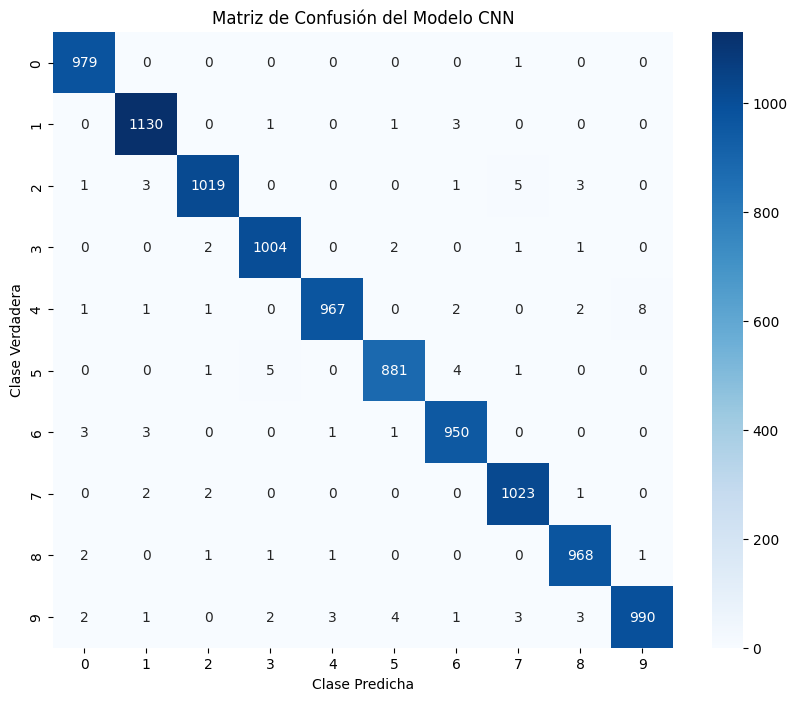

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predecir las clases en el conjunto de prueba
y_pred_cnn = cnn_model.predict(x_test_cnn)
y_pred_classes_cnn = np.argmax(y_pred_cnn, axis=1)

# Obtener las etiquetas verdaderas del conjunto de prueba (no en one-hot encoding)
y_true_classes = np.argmax(y_test_one_hot, axis=1)

# Generar la matriz de confusión
conf_matrix_cnn = confusion_matrix(y_true_classes, y_pred_classes_cnn)

print("\n## 🔢 Matriz de Confusión (CNN)")
# Visualizar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_cnn, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Verdadera')
plt.title('Matriz de Confusión del Modelo CNN')
plt.show()

In [41]:
# Evaluar el modelo CNN en el conjunto de prueba
loss_cnn, accuracy_cnn = cnn_model.evaluate(x_test_cnn, y_test_one_hot, verbose=0)

print("\n## 📊 Evaluación del Modelo CNN en el Conjunto de Prueba")
print(f"Pérdida (Loss) en el conjunto de prueba (CNN): **{loss_cnn:.4f}**")
print(f"Exactitud (Accuracy) en el conjunto de prueba (CNN): **{accuracy_cnn:.4f}**")


## 📊 Evaluación del Modelo CNN en el Conjunto de Prueba
Pérdida (Loss) en el conjunto de prueba (CNN): **0.0550**
Exactitud (Accuracy) en el conjunto de prueba (CNN): **0.9911**


EJERCICO 7

In [44]:
cnn_model_regularized.compile(optimizer='adam',
                              loss='categorical_crossentropy',
                              metrics=['accuracy'])

print("\n## ✅ Modelo CNN Regularizado Compilado")


## ✅ Modelo CNN Regularizado Compilado


EJERCICIO 8

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [47]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

print("\n## ✨ ImageDataGenerator instanciado con parámetros de aumento de datos")


## ✨ ImageDataGenerator instanciado con parámetros de aumento de datos


In [48]:
batch_size = 64
train_generator = datagen.flow(x_train_cnn, y_train_one_hot, batch_size=batch_size)

print("\n## ✨ Generador de datos de entrenamiento creado con data augmentation")
print(f"Tipo de objeto train_generator: **{type(train_generator)}**")
print(f"Tamaño del lote (batch_size): **{train_generator.batch_size}**")


## ✨ Generador de datos de entrenamiento creado con data augmentation
Tipo de objeto train_generator: **<class 'keras.src.legacy.preprocessing.image.NumpyArrayIterator'>**
Tamaño del lote (batch_size): **64**
